## SALES TABLE

In [12]:
! pip install Faker

In [13]:
import pandas as pd
import numpy as np
from faker import Faker

fake = Faker("en_AU")
np.random.seed(42)

# -----------------------------
# items (products)
# -----------------------------
items = pd.DataFrame({
    "item_id": range(1001, 1021),
    "item_name": [
        "Farmdale Full Cream Milk 2L", "Bakers Life White Bread",
        "Mamia Nappies", "Westacre Tasty Cheese Block",
        "Brookdale Canned Tuna",
        "Just Organic Eggs 12 Pack", "Elmsbury Beef Mince",
        "The Olive Tree Olive Oil", "Goldenvale Corn Flakes",
        "Belmont Chocolate Biscuits", "Alcafe Instant Coffee",
        "Lyttos Greek Yoghurt", "Diplomat Earl Grey Tea",
        "Market Fare Frozen Vegetables", "Sprinters Potato Chips",
        "Power Force Laundry Liquid", "Lacura Hand Wash",
        "Berg Smallgoods Ham", "Oh So Natural Almonds",
        "Remano Pasta Sauce"
    ],
    "department": [
        "Dairy", "Bakery", "Baby", "Dairy", "Pantry",
        "Dairy", "Meat", "Pantry", "Pantry", "Snacks",
        "Beverages", "Dairy", "Beverages", "Frozen",
        "Snacks", "Household", "Personal Care", "Deli",
        "Pantry", "Pantry"
    ],
    "category": [
        "Milk", "Bread", "Baby Care", "Cheese", "Canned Fish",
        "Eggs", "Fresh Meat", "Cooking Oil", "Breakfast Cereal", "Biscuits",
        "Coffee", "Yoghurt", "Tea", "Frozen Vegetables",
        "Chips", "Laundry", "Hand Wash", "Smallgoods",
        "Nuts", "Pasta Sauce"
    ],
    "class": [
        "Chilled Dairy", "Packaged Bakery", "Baby Essentials", "Chilled Dairy",
        "Shelf Stable Grocery", "Chilled Dairy", "Fresh Protein",
        "Shelf Stable Grocery", "Breakfast Foods", "Sweet Snacks",
        "Hot Drinks", "Chilled Dairy", "Hot Drinks", "Frozen Grocery",
        "Salty Snacks", "Cleaning Products", "Skin Care", "Chilled Deli",
        "Healthy Snacks", "Italian Grocery"
    ],
    "size": [
        "2L", "700g", "56 Pack", "500g", "425g",
        "12 Pack", "500g", "1L", "500g", "250g",
        "200g", "1kg", "50 Bags", "1kg", "175g",
        "2L", "500ml", "200g", "750g", "500g"
    ],
    "unit_price_ex_gst": [
        3.20, 2.10, 14.50, 5.80, 1.60,
        5.40, 9.80, 7.90, 3.10, 2.40,
        4.90, 4.20, 2.80, 3.50, 2.30,
        6.70, 2.20, 4.60, 7.50, 2.90
    ],
    "unit_cogs": [
        2.35, 1.40, 10.20, 4.10, 1.05,
        3.90, 7.10, 5.60, 2.10, 1.50,
        3.20, 2.90, 1.80, 2.30, 1.40,
        4.60, 1.30, 3.20, 5.30, 1.80
    ],
    "gst_rate": [
        0.00, 0.00, 0.10, 0.00, 0.00,
        0.00, 0.00, 0.00, 0.00, 0.10,
        0.10, 0.00, 0.10, 0.00, 0.10,
        0.10, 0.10, 0.00, 0.00, 0.00
    ]
})

# -----------------------------
# 5 Aldi stores in 5 Australian states
# -----------------------------

locations = pd.DataFrame({
    "location_id": [201, 202, 203, 204, 205],
    "location_name": [
        "ALDI Melbourne CBD",
        "ALDI Sydney Parramatta",
        "ALDI Brisbane South",
        "ALDI Adelaide Central",
        "ALDI Perth North"
    ],
    "state": ["VIC", "NSW", "QLD", "SA", "WA"],
    "city": ["Melbourne", "Sydney", "Brisbane", "Adelaide", "Perth"],
    "suburb": ["Melbourne CBD", "Parramatta", "South Brisbane", "Adelaide CBD", "Joondalup"],
    "postcode": [3000, 2150, 4101, 5000, 6027],
    "latitude": [-37.8136, -33.8150, -27.4748, -34.9285, -31.7445],
    "longitude": [144.9631, 151.0011, 153.0170, 138.6007, 115.7663],
    "store_size_sqm": [1350, 1650, 1500, 1400, 1750],
    "metro_regional": ["Metro", "Metro", "Metro", "Metro", "Metro"],
    "store_format": [
        "Urban Compact",
        "Suburban Standard",
        "Urban Standard",
        "CBD Compact",
        "Suburban Large"
    ],
    "parking_spaces_available": [35, 120, 80, 45, 150],
    "area_population_density": [
        "Very High",
        "High",
        "High",
        "Medium",
        "Medium"
    ],
    "area_income_level": [
        "High",
        "Medium-High",
        "Medium",
        "Medium",
        "Medium-High"
    ],
    "dominant_household_type": [
        "Young Professionals",
        "Families",
        "Students and Professionals",
        "Mixed Households",
        "Families"
    ],
    "median_age_group": [
        "25-34",
        "35-44",
        "25-34",
        "25-34",
        "35-44"
    ],
    "public_transport_access": [
        "Excellent",
        "Good",
        "Excellent",
        "Excellent",
        "Moderate"
    ]
})

customer_types = ["Retail Customer", "Loyalty Customer", "Business Customer"]
sales_types = ["Regular Sale", "Promotion Sale", "Markdown Sale"]
sales_channels = ["In-store", "Online", "Click and Collect"]

# -----------------------------
# Generate synthetic sales table
# -----------------------------
n_rows = 10000

sales = []

for _ in range(n_rows):
    item = items.sample(1).iloc[0]
    location = locations.sample(1).iloc[0]

    transaction_date = fake.date_between(
            start_date=pd.to_datetime("2025-06-01"),
            end_date=pd.to_datetime("2026-05-31")
    )
    customer_type = np.random.choice(customer_types, p=[0.65, 0.25, 0.10])
    sales_type = np.random.choice(sales_types, p=[0.70, 0.20, 0.10])
    sales_channel_type = np.random.choice(sales_channels, p=[0.82, 0.08, 0.10])

    # sales_quantity = np.random.poisson(lam=6) + 1
    base_lambda = 6

    # Weekend effect
    if transaction_date.weekday() in [5, 6]:
        base_lambda *= 1.15

    # Christmas peak
    if transaction_date.month == 12 and transaction_date.day >= 15:
        base_lambda *= 1.35

    # New Year period
    if transaction_date.month == 1 and transaction_date.day <= 7:
        base_lambda *= 1.10

    # Easter / autumn retail period
    if transaction_date.month in [3, 4]:
        base_lambda *= 1.10

    # Mid-year sales
    if transaction_date.month in [6, 7]:
        base_lambda *= 1.15

    # Promotion effect
    if sales_type == "Promotion Sale":
        base_lambda *= 1.25
    elif sales_type == "Markdown Sale":
        base_lambda *= 1.10

    sales_quantity = np.random.poisson(lam=base_lambda) + 1


    discount = 0
    if sales_type == "Promotion Sale":
        discount = np.random.uniform(0.05, 0.20)
    elif sales_type == "Markdown Sale":
        discount = np.random.uniform(0.20, 0.45)

    unit_price_ex_gst = item["unit_price_ex_gst"] * (1 - discount)

    total_sales_ex_gst = sales_quantity * unit_price_ex_gst
    total_gst = total_sales_ex_gst * item["gst_rate"]
    total_sales_inc_gst = total_sales_ex_gst + total_gst
    total_cogs = sales_quantity * item["unit_cogs"]
    total_gp_margin = total_sales_ex_gst - total_cogs

    sales.append({
        "item_id": item["item_id"],
        "item_name": item["item_name"],
        "department": item["department"],
        "category": item["category"],
        "class": item["class"],
        "size": item["size"],

        "location_id": location["location_id"],
        "location_name": location["location_name"],
        "state": location["state"],
        "city": location["city"],
        "suburb": location["suburb"],
        "postcode": location["postcode"],
        "latitude": location["latitude"],
        "longitude": location["longitude"],
        "store_size_sqm": location["store_size_sqm"],
        "store_format": location["store_format"],
        "metro_regional": location["metro_regional"],
        "parking_spaces_available": location["parking_spaces_available"],
        "area_population_density": location["area_population_density"],
        "area_income_level": location["area_income_level"],
        "dominant_household_type": location["dominant_household_type"],
        "median_age_group": location["median_age_group"],
        "public_transport_access": location["public_transport_access"],

        "transaction_date": transaction_date,
        "customer_type": customer_type,
        "sales_type": sales_type,
        "sales_channel_type": sales_channel_type,
        "sales_quantity": sales_quantity,
        "total_sales_exclude_gst_amount": round(total_sales_ex_gst, 2),
        "total_sales_include_gst_amount": round(total_sales_inc_gst, 2),
        "total_sales_gst_amount": round(total_gst, 2),
        "total_cogs_amount": round(total_cogs, 2),
        "total_gp_margin_amount": round(total_gp_margin, 2)
    })

sales_df = pd.DataFrame(sales)

# sales_df.to_csv("synthetic_aldi_sales_2021_2027.csv", index=False)

# print(sales_df.head())
# print(sales_df.shape)
# print(sales_df["state"].value_counts())
# print(sales_df["transaction_date"].min(), sales_df["transaction_date"].max())

## HOLIDAYS

In [14]:
import pandas as pd
import holidays

states = ["VIC", "NSW", "QLD", "SA", "WA"]
years = [2025, 2026]

public_rows = []

for state in states:
    au_holidays = holidays.Australia(years=years, subdiv=state)

    for holiday_date, holiday_name in au_holidays.items():
        public_rows.append({
            "state": state,
            "holiday_date": pd.to_datetime(holiday_date),
            "holiday_name": holiday_name,
            "holiday_type": "public_holiday"
        })

public_holidays_df = pd.DataFrame(public_rows)

In [15]:
school_holiday_ranges = {
    "VIC": [
        ("2025-04-05", "2025-04-21", "Autumn school holidays"),
        ("2025-07-05", "2025-07-20", "Winter school holidays"),
        ("2025-09-20", "2025-10-05", "Spring school holidays"),
        ("2025-12-20", "2026-01-27", "Summer school holidays"),

        ("2026-04-03", "2026-04-19", "Autumn school holidays"),
        ("2026-06-27", "2026-07-12", "Winter school holidays"),
        ("2026-09-19", "2026-10-04", "Spring school holidays"),
        ("2026-12-19", "2027-01-27", "Summer school holidays"),
    ],
    "NSW": [
        ("2025-04-12", "2025-04-27", "Autumn school holidays"),
        ("2025-07-05", "2025-07-20", "Winter school holidays"),
        ("2025-09-27", "2025-10-12", "Spring school holidays"),
        ("2025-12-20", "2026-02-01", "Summer school holidays"),

        ("2026-04-03", "2026-04-21", "Autumn school holidays"),
        ("2026-07-04", "2026-07-20", "Winter school holidays"),
        ("2026-09-26", "2026-10-12", "Spring school holidays"),
        ("2026-12-18", "2027-01-27", "Summer school holidays"),
    ],
    "QLD": [
        ("2025-04-05", "2025-04-21", "Autumn school holidays"),
        ("2025-06-28", "2025-07-13", "Winter school holidays"),
        ("2025-09-20", "2025-10-06", "Spring school holidays"),
        ("2025-12-13", "2026-01-26", "Summer school holidays"),

        ("2026-04-03", "2026-04-19", "Autumn school holidays"),
        ("2026-06-27", "2026-07-12", "Winter school holidays"),
        ("2026-09-19", "2026-10-05", "Spring school holidays"),
        ("2026-12-12", "2027-01-26", "Summer school holidays"),
    ],
    "SA": [
        ("2025-04-12", "2025-04-27", "Autumn school holidays"),
        ("2025-07-05", "2025-07-20", "Winter school holidays"),
        ("2025-09-27", "2025-10-12", "Spring school holidays"),
        ("2025-12-13", "2026-01-26", "Summer school holidays"),

        ("2026-04-11", "2026-04-26", "Autumn school holidays"),
        ("2026-07-04", "2026-07-19", "Winter school holidays"),
        ("2026-09-26", "2026-10-11", "Spring school holidays"),
        ("2026-12-12", "2027-01-26", "Summer school holidays"),
    ],
    "WA": [
        ("2025-04-12", "2025-04-27", "Autumn school holidays"),
        ("2025-07-05", "2025-07-20", "Winter school holidays"),
        ("2025-09-27", "2025-10-12", "Spring school holidays"),
        ("2025-12-19", "2026-02-01", "Summer school holidays"),

        ("2026-04-03", "2026-04-19", "Autumn school holidays"),
        ("2026-07-04", "2026-07-19", "Winter school holidays"),
        ("2026-09-26", "2026-10-11", "Spring school holidays"),
        ("2026-12-18", "2027-01-31", "Summer school holidays"),
    ]
}

school_rows = []

for state, ranges in school_holiday_ranges.items():
    for start, end, name in ranges:
        for date in pd.date_range(start=start, end=end):
            school_rows.append({
                "state": state,
                "holiday_date": date,
                "holiday_name": name,
                "holiday_type": "school_holiday"
            })

school_holidays_df = pd.DataFrame(school_rows)

In [16]:
all_holidays_df = pd.concat(
    [public_holidays_df, school_holidays_df],
    ignore_index=True
)

all_holidays_df = all_holidays_df.sort_values(
    ["state", "holiday_date", "holiday_type"]
).reset_index(drop=True)

In [17]:
sales_df["transaction_date"] = pd.to_datetime(
    sales_df["transaction_date"]
).dt.normalize()

all_holidays_df["holiday_date"] = pd.to_datetime(
    all_holidays_df["holiday_date"]
).dt.normalize()

In [18]:
sales_with_holidays = sales_df.merge(
    all_holidays_df,
    left_on=["state", "transaction_date"],
    right_on=["state", "holiday_date"],
    how="left"
)

sales_with_holidays["is_public_holiday"] = (
    sales_with_holidays["holiday_type"].eq("public_holiday")
)

sales_with_holidays["is_school_holiday"] = (
    sales_with_holidays["holiday_type"].eq("school_holiday")
)

In [19]:
sales_with_holidays

,item_id,item_name,department,category,class,size,location_id,location_name,state,city,...,total_sales_exclude_gst_amount,total_sales_include_gst_amount,total_sales_gst_amount,total_cogs_amount,total_gp_margin_amount,holiday_date,holiday_name,holiday_type,is_public_holiday,is_school_holiday
0,1001,Farmdale Full Cream Milk 2L,Dairy,Milk,Chilled Dairy,2L,205,ALDI Perth North,WA,Perth,...,19.20,19.20,0.00,14.1,5.10,NaT,NaN,NaN,False,False
1,1020,Remano Pasta Sauce,Pantry,Pasta Sauce,Italian Grocery,500g,201,ALDI Melbourne CBD,VIC,Melbourne,...,34.80,34.80,0.00,21.6,13.20,NaT,NaN,NaN,False,False
2,1017,Lacura Hand Wash,Personal Care,Hand Wash,Skin Care,500ml,202,ALDI Sydney Parramatta,NSW,Sydney,...,11.00,12.10,1.10,6.5,4.50,2026-04-18,Autumn school holidays,school_holiday,False,True
3,1013,Diplomat Earl Grey Tea,Beverages,Tea,Hot Drinks,50 Bags,202,ALDI Sydney Parramatta,NSW,Sydney,...,15.45,17.00,1.55,10.8,4.65,NaT,NaN,NaN,False,False
4,1008,The Olive Tree Olive Oil,Pantry,Cooking Oil,Shelf Stable Grocery,1L,201,ALDI Melbourne CBD,VIC,Melbourne,...,48.30,48.30,0.00,39.2,9.10,NaT,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10238,1013,Diplomat Earl Grey Tea,Beverages,Tea,Hot Drinks,50 Bags,201,ALDI Melbourne CBD,VIC,Melbourne,...,16.80,18.48,1.68,10.8,6.00,NaT,NaN,NaN,False,False
10239,1014,Market Fare Frozen Vegetables,Frozen,Frozen Vegetables,Frozen Grocery,1kg,201,ALDI Melbourne CBD,VIC,Melbourne,...,45.50,45.50,0.00,29.9,15.60,NaT,NaN,NaN,False,False
10240,1002,Bakers Life White Bread,Bakery,Bread,Packaged Bakery,700g,205,ALDI Perth North,WA,Perth,...,14.70,14.70,0.00,9.8,4.90,NaT,NaN,NaN,False,False
10241,1019,Oh So Natural Almonds,Pantry,Nuts,Healthy Snacks,750g,203,ALDI Brisbane South,QLD,Brisbane,...,45.00,45.00,0.00,31.8,13.20,NaT,NaN,NaN,False,False


In [20]:
sales_with_holidays.columns

Index(['item_id', 'item_name', 'department', 'category', 'class', 'size',
       'location_id', 'location_name', 'state', 'city', 'suburb', 'postcode',
       'latitude', 'longitude', 'store_size_sqm', 'store_format',
       'metro_regional', 'parking_spaces_available', 'area_population_density',
       'area_income_level', 'dominant_household_type', 'median_age_group',
       'public_transport_access', 'transaction_date', 'customer_type',
       'sales_type', 'sales_channel_type', 'sales_quantity',
       'total_sales_exclude_gst_amount', 'total_sales_include_gst_amount',
       'total_sales_gst_amount', 'total_cogs_amount', 'total_gp_margin_amount',
       'holiday_date', 'holiday_name', 'holiday_type', 'is_public_holiday',
       'is_school_holiday'],
      dtype='object')

# PREDICTION

Training period:
2025-06-01 00:00:00 to 2026-03-18 00:00:00

Testing period:
2026-03-19 00:00:00 to 2026-05-30 00:00:00

Model Accuracy Summary:
              Metric       Value
0                MAE  184.638507
1               RMSE  204.257155
2           MAPE (%)   78.225709
3          WMAPE (%)   79.968028
4  Forecast Bias (%)  -78.197657
5                 R2   -8.895512


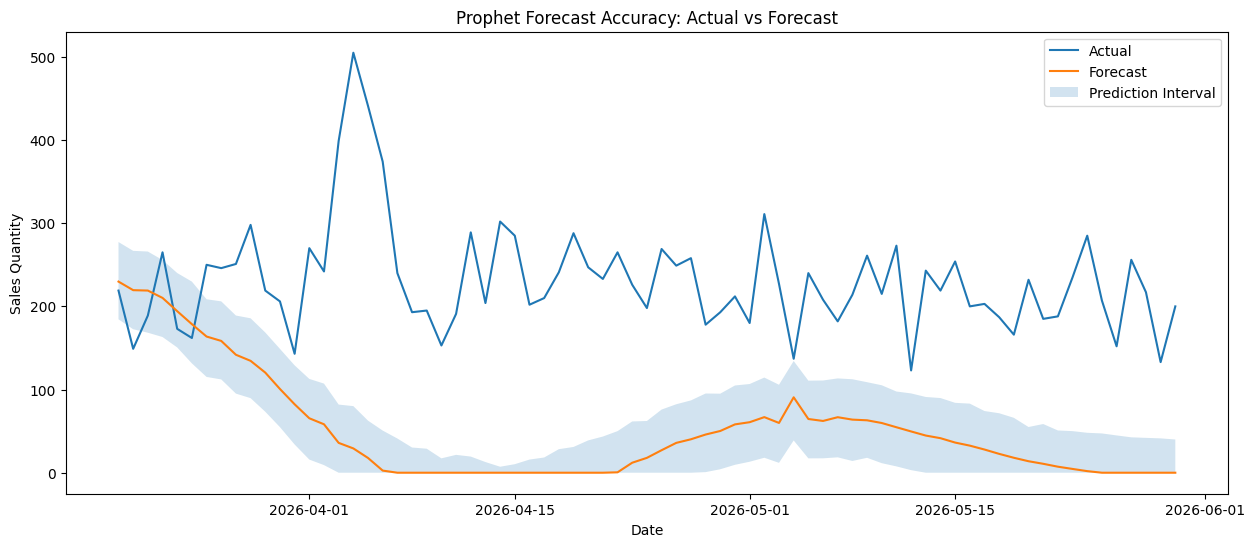


180-Day Future Forecast:
            ds  expected_sales_volume  lower_bound  upper_bound       trend
364 2026-05-31                    216          166          265  192.075679
365 2026-06-01                    189          140          240  191.958069
366 2026-06-02                    177          124          226  191.840460
367 2026-06-03                    181          132          231  191.722850
368 2026-06-04                    193          140          247  191.605240
            ds  expected_sales_volume  lower_bound  upper_bound       trend
539 2026-11-22                    199          144          250  171.493971
540 2026-11-23                    173          121          225  171.376361
541 2026-11-24                    162          113          213  171.258751
542 2026-11-25                    164          109          216  171.141141
543 2026-11-26                    173          118          227  171.023532

Files saved:
1. retail_sales_180_day_forecast_prophet.csv
2. 

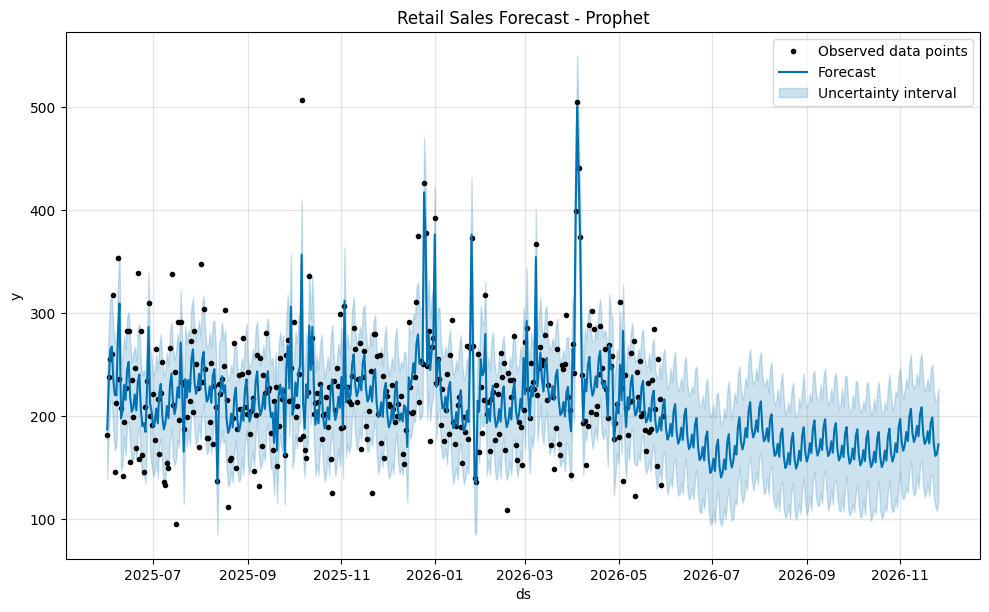

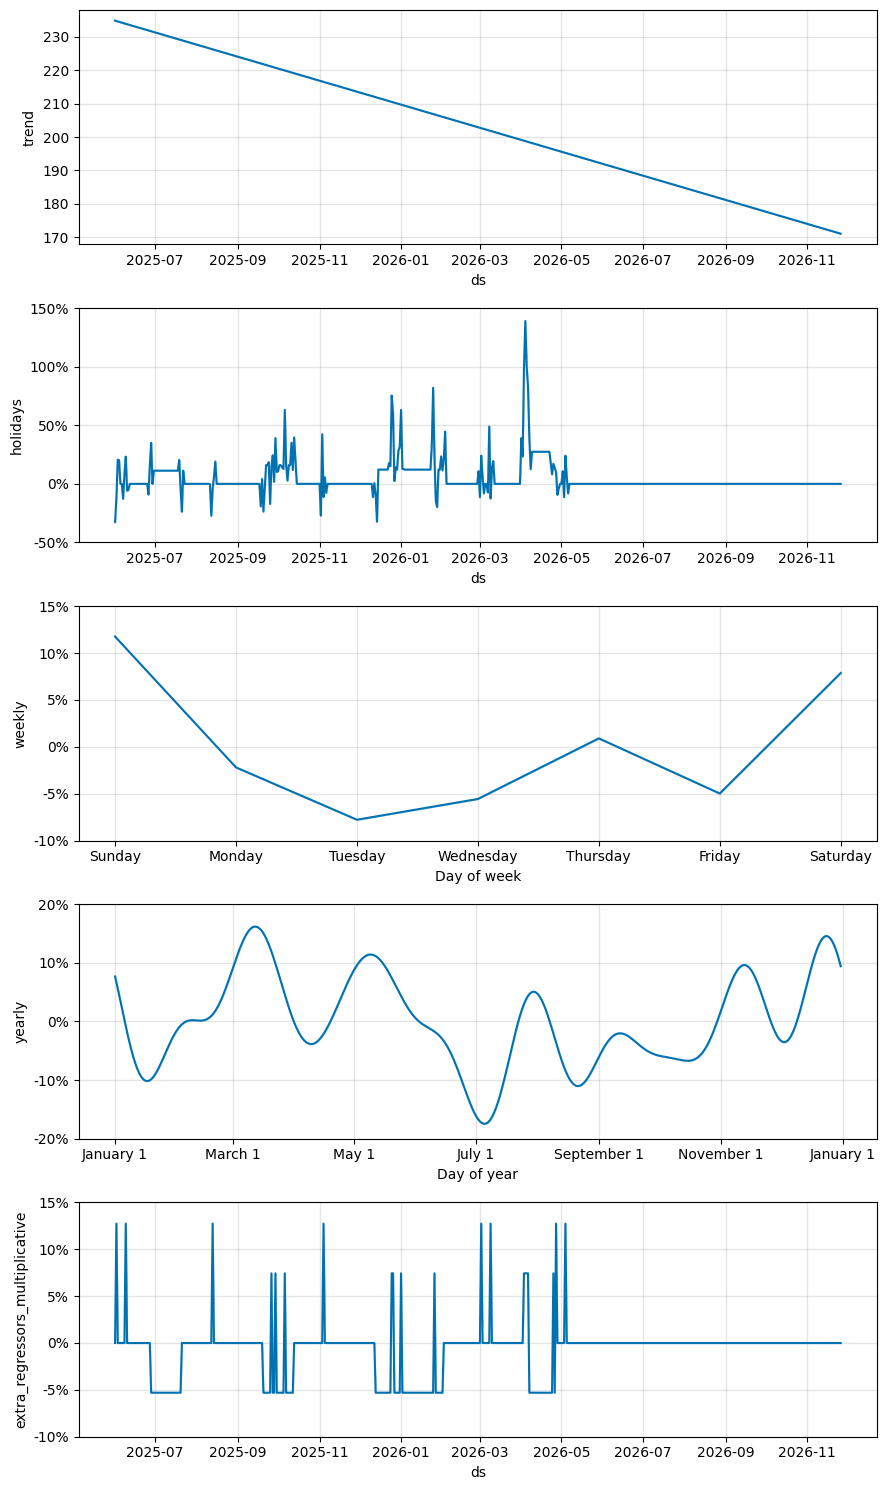

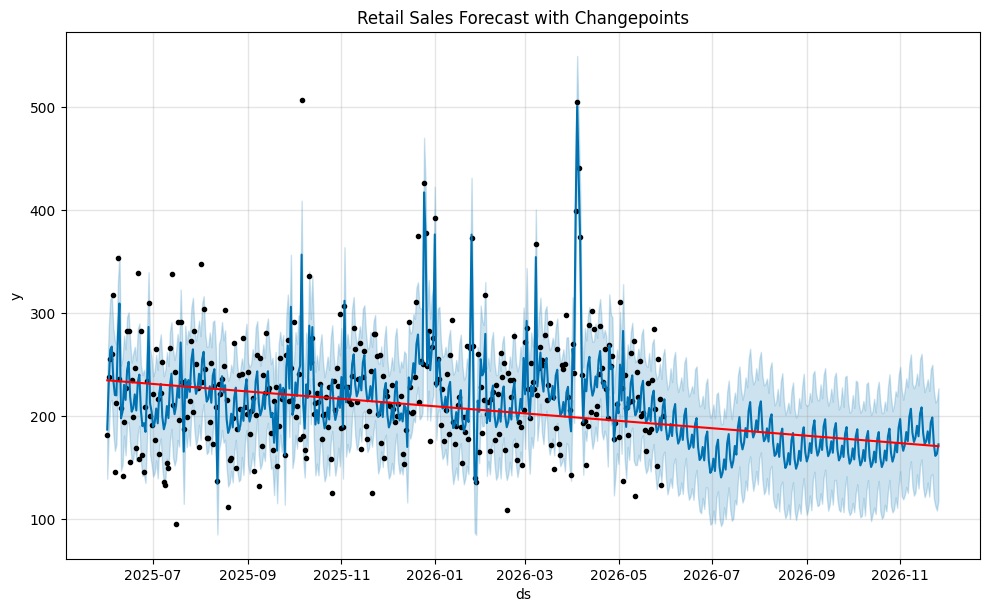

  0%|          | 0/3 [00:00<?, ?it/s]


Prophet Cross-Validation Performance:
  horizon           mse        rmse         mae      mape     mdape     smape  \
0  6 days  21760.946567  147.515920  101.110057  0.303710  0.226621  0.383380   
1  7 days  23235.139868  152.430771  107.268954  0.322986  0.239158  0.415107   
2  8 days  23567.647173  153.517579  107.571425  0.324045  0.239158  0.417418   
3  9 days  20302.273004  142.486045   96.940478  0.305714  0.218597  0.390428   
4 10 days  13012.969496  114.074403   78.490221  0.287003  0.231617  0.349275   

   coverage  
0  0.500000  
1  0.500000  
2  0.500000  
3  0.500000  
4  0.444444  


In [10]:
# ============================================================
# Retail Sales Forecasting with Prophet + Accuracy Evaluation
# Dataset: sales_with_holidays
# Forecast horizon: 180 days
# ============================================================

# pip install prophet scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
from prophet.diagnostics import cross_validation, performance_metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
import logging

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)


# ============================================================
# 1. Prepare data
# ============================================================

df = sales_with_holidays.copy()

df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["sales_quantity"] = pd.to_numeric(df["sales_quantity"], errors="coerce").fillna(0)

# Daily total sales volume
daily_sales = (
    df.groupby("transaction_date", as_index=False)
      .agg({"sales_quantity": "sum"})
      .rename(columns={
          "transaction_date": "ds",
          "sales_quantity": "y"
      })
)

daily_sales = daily_sales.sort_values("ds").reset_index(drop=True)


# ============================================================
# 2. Prepare holiday data for Prophet
# ============================================================

holiday_df = df[df["holiday_date"].notna()].copy()

if len(holiday_df) > 0:
    holiday_df["holiday_date"] = pd.to_datetime(holiday_df["holiday_date"])

    holidays = (
        holiday_df[["holiday_date", "holiday_name"]]
        .drop_duplicates()
        .rename(columns={
            "holiday_date": "ds",
            "holiday_name": "holiday"
        })
    )

    holidays = holidays[["holiday", "ds"]]
    holidays["lower_window"] = -2
    holidays["upper_window"] = 2

else:
    holidays = pd.DataFrame(columns=["holiday", "ds", "lower_window", "upper_window"])


# ============================================================
# 3. Add holiday indicators / regressors
# ============================================================

daily_features = (
    df.groupby("transaction_date", as_index=False)
      .agg({
          "is_public_holiday": "max",
          "is_school_holiday": "max"
      })
      .rename(columns={"transaction_date": "ds"})
)

daily_features["ds"] = pd.to_datetime(daily_features["ds"])

daily_sales = daily_sales.merge(daily_features, on="ds", how="left")

daily_sales["is_public_holiday"] = daily_sales["is_public_holiday"].fillna(0).astype(int)
daily_sales["is_school_holiday"] = daily_sales["is_school_holiday"].fillna(0).astype(int)


# ============================================================
# 4. Train-test split for model accuracy
# ============================================================

daily_sales = daily_sales.sort_values("ds").reset_index(drop=True)

split_idx = int(len(daily_sales) * 0.8)

train = daily_sales.iloc[:split_idx].copy()
test = daily_sales.iloc[split_idx:].copy()

print("Training period:")
print(train["ds"].min(), "to", train["ds"].max())

print("\nTesting period:")
print(test["ds"].min(), "to", test["ds"].max())


# ============================================================
# 5. Train Prophet model on training data
# ============================================================

model_test = Prophet(
    holidays=holidays,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.08,
    seasonality_prior_scale=10,
    holidays_prior_scale=10
)

model_test.add_regressor("is_public_holiday")
model_test.add_regressor("is_school_holiday")

model_test.fit(train)


# ============================================================
# 6. Forecast test period
# ============================================================

future_test = test[[
    "ds",
    "is_public_holiday",
    "is_school_holiday"
]].copy()

forecast_test = model_test.predict(future_test)

results = test.merge(
    forecast_test[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds",
    how="left"
)

results["yhat"] = results["yhat"].clip(lower=0)


# ============================================================
# 7. Accuracy metrics
# ============================================================

actual = results["y"]
predicted = results["yhat"]

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

# Avoid division by zero in MAPE
non_zero_mask = actual != 0
mape = np.mean(
    np.abs((actual[non_zero_mask] - predicted[non_zero_mask]) / actual[non_zero_mask])
) * 100

wmape = (
    np.sum(np.abs(actual - predicted)) / np.sum(actual)
) * 100

forecast_bias = (
    np.sum(predicted - actual) / np.sum(actual)
) * 100

r2 = r2_score(actual, predicted)

accuracy_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE (%)", "WMAPE (%)", "Forecast Bias (%)", "R2"],
    "Value": [mae, rmse, mape, wmape, forecast_bias, r2]
})

print("\nModel Accuracy Summary:")
print(accuracy_summary)


# ============================================================
# 8. Plot actual vs predicted test data
# ============================================================

plt.figure(figsize=(15, 6))
plt.plot(results["ds"], results["y"], label="Actual")
plt.plot(results["ds"], results["yhat"], label="Forecast")
plt.fill_between(
    results["ds"],
    results["yhat_lower"].clip(lower=0),
    results["yhat_upper"].clip(lower=0),
    alpha=0.2,
    label="Prediction Interval"
)
plt.title("Prophet Forecast Accuracy: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Sales Quantity")
plt.legend()
plt.show()


# ============================================================
# 9. Train final model on full historical data
# ============================================================

final_model = Prophet(
    holidays=holidays,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.08,
    seasonality_prior_scale=10,
    holidays_prior_scale=10
)

final_model.add_regressor("is_public_holiday")
final_model.add_regressor("is_school_holiday")

final_model.fit(daily_sales)


# ============================================================
# 10. Create future dataframe for 180 days
# ============================================================

future = final_model.make_future_dataframe(periods=180, freq="D")

# Merge known historical indicators
future = future.merge(daily_features, on="ds", how="left")

# For future unknown holiday flags, fill with 0
future["is_public_holiday"] = future["is_public_holiday"].fillna(0).astype(int)
future["is_school_holiday"] = future["is_school_holiday"].fillna(0).astype(int)


# ============================================================
# 11. Generate 180-day forecast
# ============================================================

forecast = final_model.predict(future)

last_history_date = daily_sales["ds"].max()

future_forecast = forecast[forecast["ds"] > last_history_date].copy()

future_forecast["expected_sales_volume"] = (
    future_forecast["yhat"]
    .clip(lower=0)
    .round()
    .astype(int)
)

future_forecast["lower_bound"] = (
    future_forecast["yhat_lower"]
    .clip(lower=0)
    .round()
    .astype(int)
)

future_forecast["upper_bound"] = (
    future_forecast["yhat_upper"]
    .clip(lower=0)
    .round()
    .astype(int)
)

future_forecast = future_forecast[[
    "ds",
    "expected_sales_volume",
    "lower_bound",
    "upper_bound",
    "trend"
]]

print("\n180-Day Future Forecast:")
print(future_forecast.head())
print(future_forecast.tail())


# ============================================================
# 12. Save outputs
# ============================================================

future_forecast.to_csv("retail_sales_180_day_forecast_prophet.csv", index=False)
accuracy_summary.to_csv("retail_sales_prophet_accuracy_summary.csv", index=False)
results.to_csv("retail_sales_prophet_test_results.csv", index=False)

print("\nFiles saved:")
print("1. retail_sales_180_day_forecast_prophet.csv")
print("2. retail_sales_prophet_accuracy_summary.csv")
print("3. retail_sales_prophet_test_results.csv")


# ============================================================
# 13. Plot full forecast
# ============================================================

fig1 = final_model.plot(forecast, include_legend=True)
plt.title("Retail Sales Forecast - Prophet")
plt.show()

fig2 = final_model.plot_components(forecast)
plt.show()

fig3 = final_model.plot(forecast)
add_changepoints_to_plot(fig3.gca(), final_model, forecast)
plt.title("Retail Sales Forecast with Changepoints")
plt.show()


# ============================================================
# 14. Optional Prophet cross-validation
# ============================================================

try:
    df_cv = cross_validation(
        final_model,
        initial="240 days",
        period="30 days",
        horizon="60 days"
    )

    df_performance = performance_metrics(df_cv)

    print("\nProphet Cross-Validation Performance:")
    print(df_performance.head())

    df_performance.to_csv("retail_sales_prophet_cross_validation.csv", index=False)

except Exception as e:
    print("\nCross-validation skipped due to error:")
    print(e)

Training period: 2025-07-01 00:00:00 to 2026-03-24 00:00:00
Testing period : 2026-03-25 00:00:00 to 2026-05-30 00:00:00

Accuracy Summary:
              Metric      Value
0                MAE  44.475256
1               RMSE  57.344681
2           MAPE (%)  19.857705
3          WMAPE (%)  18.982305
4  Forecast Bias (%)  -3.537979
5                 R2   0.237998


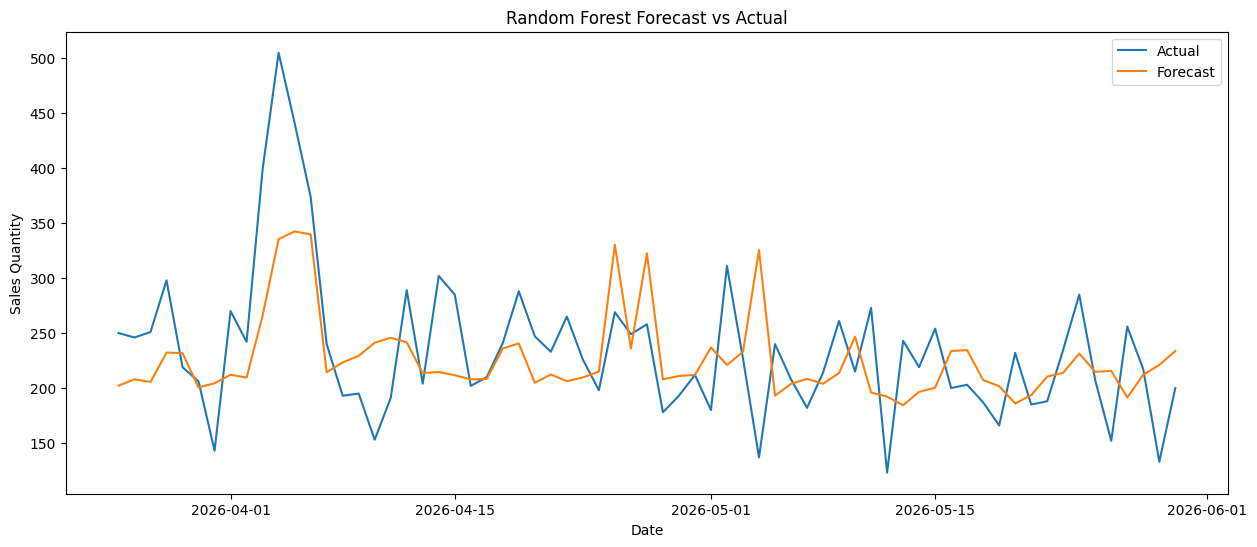


Feature Importance:
                     Feature  Importance
7          is_public_holiday    0.131769
18           rolling_mean_14    0.115410
17            rolling_mean_7    0.089072
13                     lag_1    0.077686
1                 dayofmonth    0.069187
20             rolling_std_7    0.068694
14                     lag_7    0.068465
16                    lag_30    0.065022
15                    lag_14    0.058491
0                  dayofweek    0.055230
19           rolling_mean_30    0.052059
21            rolling_std_30    0.043967
4                 weekofyear    0.041501
6                 is_weekend    0.020607
9        is_christmas_period    0.014370
2                      month    0.010727
8          is_school_holiday    0.007799
3                    quarter    0.004203
11          is_easter_period    0.003301
12  is_mid_year_sales_period    0.001846
5                       year    0.000588
10        is_new_year_period    0.000005

180-Day Randomised Forecast:
      

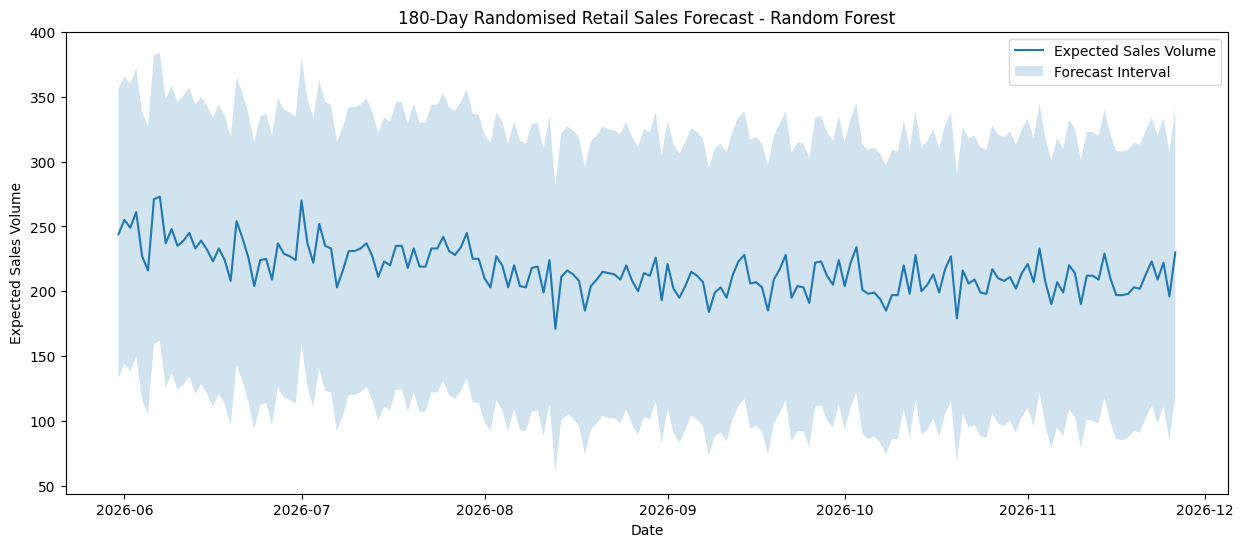

In [11]:
# ============================================================
# Retail Sales Forecasting using Random Forest
# Historical period: 1 year
# Forecast horizon: 180 days
# Includes: seasonal peaks, holidays, random demand shifts
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. PREPARE DATA
# ============================================================

df = sales_with_holidays.copy()

df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["sales_quantity"] = pd.to_numeric(df["sales_quantity"], errors="coerce").fillna(0)

df["is_public_holiday"] = df["is_public_holiday"].fillna(0).astype(int)
df["is_school_holiday"] = df["is_school_holiday"].fillna(0).astype(int)


# ============================================================
# 2. DAILY SALES AGGREGATION
# ============================================================

daily_sales = (
    df.groupby("transaction_date", as_index=False)
      .agg({
          "sales_quantity": "sum",
          "is_public_holiday": "max",
          "is_school_holiday": "max"
      })
      .rename(columns={
          "transaction_date": "ds",
          "sales_quantity": "y"
      })
)

daily_sales = daily_sales.sort_values("ds").reset_index(drop=True)


# ============================================================
# 3. CREATE CALENDAR + SEASONAL FEATURES
# ============================================================

def add_calendar_features(data):
    data = data.copy()

    data["dayofweek"] = data["ds"].dt.dayofweek
    data["dayofmonth"] = data["ds"].dt.day
    data["month"] = data["ds"].dt.month
    data["quarter"] = data["ds"].dt.quarter
    data["weekofyear"] = data["ds"].dt.isocalendar().week.astype(int)
    data["year"] = data["ds"].dt.year

    data["is_weekend"] = data["dayofweek"].isin([5, 6]).astype(int)

    # Known seasonal retail peaks
    data["is_christmas_period"] = (
        (data["month"] == 12) & (data["dayofmonth"] >= 15)
    ).astype(int)

    data["is_new_year_period"] = (
        (data["month"] == 1) & (data["dayofmonth"] <= 7)
    ).astype(int)

    data["is_easter_period"] = (
        data["month"].isin([3, 4])
    ).astype(int)

    data["is_mid_year_sales_period"] = (
        data["month"].isin([6, 7])
    ).astype(int)

    return data


daily_sales = add_calendar_features(daily_sales)


# ============================================================
# 4. CREATE LAG + ROLLING FEATURES
# ============================================================

def add_lag_features(data):
    data = data.copy()

    data["lag_1"] = data["y"].shift(1)
    data["lag_7"] = data["y"].shift(7)
    data["lag_14"] = data["y"].shift(14)
    data["lag_30"] = data["y"].shift(30)

    data["rolling_mean_7"] = data["y"].shift(1).rolling(7).mean()
    data["rolling_mean_14"] = data["y"].shift(1).rolling(14).mean()
    data["rolling_mean_30"] = data["y"].shift(1).rolling(30).mean()

    data["rolling_std_7"] = data["y"].shift(1).rolling(7).std()
    data["rolling_std_30"] = data["y"].shift(1).rolling(30).std()

    return data


daily_sales = add_lag_features(daily_sales)
daily_sales = daily_sales.dropna().reset_index(drop=True)


# ============================================================
# 5. FEATURE LIST
# ============================================================

FEATURES = [
    "dayofweek",
    "dayofmonth",
    "month",
    "quarter",
    "weekofyear",
    "year",
    "is_weekend",
    "is_public_holiday",
    "is_school_holiday",
    "is_christmas_period",
    "is_new_year_period",
    "is_easter_period",
    "is_mid_year_sales_period",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",
    "rolling_std_7",
    "rolling_std_30"
]

TARGET = "y"


# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

split_idx = int(len(daily_sales) * 0.8)

train = daily_sales.iloc[:split_idx].copy()
test = daily_sales.iloc[split_idx:].copy()

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

print("Training period:", train["ds"].min(), "to", train["ds"].max())
print("Testing period :", test["ds"].min(), "to", test["ds"].max())


# ============================================================
# 7. TRAIN RANDOM FOREST
# ============================================================

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


# ============================================================
# 8. TEST FORECAST
# ============================================================

test_predictions = model.predict(X_test)
test_predictions = np.clip(test_predictions, 0, None)

results = test[["ds", "y"]].copy()
results["Forecast"] = test_predictions


# ============================================================
# 9. ACCURACY METRICS
# ============================================================

mae = mean_absolute_error(y_test, test_predictions)
rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

non_zero_mask = y_test != 0

mape = np.mean(
    np.abs((y_test[non_zero_mask] - test_predictions[non_zero_mask]) / y_test[non_zero_mask])
) * 100

wmape = (
    np.sum(np.abs(y_test - test_predictions)) / np.sum(y_test)
) * 100

forecast_bias = (
    np.sum(test_predictions - y_test) / np.sum(y_test)
) * 100

r2 = r2_score(y_test, test_predictions)

accuracy_summary = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "MAPE (%)",
        "WMAPE (%)",
        "Forecast Bias (%)",
        "R2"
    ],
    "Value": [
        mae,
        rmse,
        mape,
        wmape,
        forecast_bias,
        r2
    ]
})

print("\nAccuracy Summary:")
print(accuracy_summary)


# ============================================================
# 10. PLOT TEST RESULTS
# ============================================================

plt.figure(figsize=(15, 6))
plt.plot(results["ds"], results["y"], label="Actual")
plt.plot(results["ds"], results["Forecast"], label="Forecast")
plt.title("Random Forest Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Sales Quantity")
plt.legend()
plt.show()


# ============================================================
# 11. FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance)


# ============================================================
# 12. TRAIN FINAL MODEL ON FULL 1-YEAR DATA
# ============================================================

X_full = daily_sales[FEATURES]
y_full = daily_sales[TARGET]

final_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_full, y_full)


# ============================================================
# 13. PREPARE FUTURE HOLIDAY FLAGS
# ============================================================

holiday_flags = (
    df.groupby("holiday_date", as_index=False)
      .agg({
          "is_public_holiday": "max",
          "is_school_holiday": "max"
      })
      .rename(columns={"holiday_date": "ds"})
)

holiday_flags["ds"] = pd.to_datetime(holiday_flags["ds"])


# ============================================================
# 14. ITERATIVE 180-DAY RANDOMISED FORECAST
# ============================================================

np.random.seed(42)

future_data = daily_sales.copy()
future_predictions = []

test_error_std = np.std(results["y"] - results["Forecast"])

for i in range(180):

    next_date = future_data["ds"].max() + pd.Timedelta(days=1)

    temp = pd.DataFrame({
        "ds": [next_date],
        "y": [np.nan]
    })

    temp = add_calendar_features(temp)

    matched_holiday = holiday_flags[holiday_flags["ds"] == next_date]

    if len(matched_holiday) > 0:
        temp["is_public_holiday"] = int(matched_holiday["is_public_holiday"].iloc[0])
        temp["is_school_holiday"] = int(matched_holiday["is_school_holiday"].iloc[0])
    else:
        temp["is_public_holiday"] = 0
        temp["is_school_holiday"] = 0

    temp["lag_1"] = future_data["y"].iloc[-1]
    temp["lag_7"] = future_data["y"].iloc[-7]
    temp["lag_14"] = future_data["y"].iloc[-14]
    temp["lag_30"] = future_data["y"].iloc[-30]

    temp["rolling_mean_7"] = future_data["y"].iloc[-7:].mean()
    temp["rolling_mean_14"] = future_data["y"].iloc[-14:].mean()
    temp["rolling_mean_30"] = future_data["y"].iloc[-30:].mean()

    temp["rolling_std_7"] = future_data["y"].iloc[-7:].std()
    temp["rolling_std_30"] = future_data["y"].iloc[-30:].std()

    X_future = temp[FEATURES]

    base_prediction = final_model.predict(X_future)[0]
    base_prediction = max(0, base_prediction)

    # Random demand movement
    demand_shift = np.random.normal(loc=1.00, scale=0.05)

    # Seasonal peak adjustments
    if temp["is_christmas_period"].iloc[0] == 1:
        demand_shift *= 1.20

    if temp["is_new_year_period"].iloc[0] == 1:
        demand_shift *= 1.08

    if temp["is_easter_period"].iloc[0] == 1:
        demand_shift *= 1.10

    if temp["is_mid_year_sales_period"].iloc[0] == 1:
        demand_shift *= 1.12

    if temp["is_public_holiday"].iloc[0] == 1:
        demand_shift *= 1.10

    if temp["is_school_holiday"].iloc[0] == 1:
        demand_shift *= 1.07

    expected_sales_volume = base_prediction * demand_shift
    expected_sales_volume = max(0, expected_sales_volume)

    temp["y"] = expected_sales_volume

    future_data = pd.concat(
        [future_data, temp],
        ignore_index=True
    )

    future_predictions.append({
        "date": next_date,
        "expected_sales_volume": round(expected_sales_volume),
        "base_prediction": round(base_prediction),
        "random_demand_shift_factor": round(demand_shift, 3),
        "lower_bound": max(0, round(expected_sales_volume - 1.96 * test_error_std)),
        "upper_bound": round(expected_sales_volume + 1.96 * test_error_std),
        "is_public_holiday": int(temp["is_public_holiday"].iloc[0]),
        "is_school_holiday": int(temp["is_school_holiday"].iloc[0]),
        "is_weekend": int(temp["is_weekend"].iloc[0]),
        "is_christmas_period": int(temp["is_christmas_period"].iloc[0]),
        "is_new_year_period": int(temp["is_new_year_period"].iloc[0]),
        "is_easter_period": int(temp["is_easter_period"].iloc[0]),
        "is_mid_year_sales_period": int(temp["is_mid_year_sales_period"].iloc[0])
    })


# ============================================================
# 15. FORECAST OUTPUT
# ============================================================

future_forecast = pd.DataFrame(future_predictions)

print("\n180-Day Randomised Forecast:")
print(future_forecast.head())
print(future_forecast.tail())


# ============================================================
# 16. SAVE OUTPUTS
# ============================================================

future_forecast.to_csv(
    "retail_sales_180_day_randomised_forecast_random_forest.csv",
    index=False
)

accuracy_summary.to_csv(
    "random_forest_accuracy_summary.csv",
    index=False
)

results.to_csv(
    "random_forest_test_results.csv",
    index=False
)

feature_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

print("\nFiles saved:")
print("1. retail_sales_180_day_randomised_forecast_random_forest.csv")
print("2. random_forest_accuracy_summary.csv")
print("3. random_forest_test_results.csv")
print("4. random_forest_feature_importance.csv")


# ============================================================
# 17. PLOT 180-DAY RANDOMISED FORECAST
# ============================================================

plt.figure(figsize=(15, 6))
plt.plot(
    future_forecast["date"],
    future_forecast["expected_sales_volume"],
    label="Expected Sales Volume"
)
plt.fill_between(
    future_forecast["date"],
    future_forecast["lower_bound"],
    future_forecast["upper_bound"],
    alpha=0.2,
    label="Forecast Interval"
)
plt.title("180-Day Randomised Retail Sales Forecast - Random Forest")
plt.xlabel("Date")
plt.ylabel("Expected Sales Volume")
plt.legend()
plt.show()